In [13]:
## EXAMINING NON LINERA MODELS ##

In [14]:
#DID THESE IN THE TERMINAL BEFORE STARTING THE SESSION - MIGHT USE IT MIGHT NOT USE IT
#conda activate pred_env
#pip install pygam

In [15]:
#Importing and splitting the data into test and train
import pandas as pd
data = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/codes/Data/earning.csv')
train = data.sample(frac = 0.7,random_state=617)
test = data.drop(labels = train.index)

In [16]:
#importing ols and indexing reg  to the train data and model to the remaining data after train data is removed
from statsmodels.formula.api import ols
reg = ols('earn~age', data = train)
model = reg.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   earn   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     4.580
Date:                Thu, 23 Oct 2025   Prob (F-statistic):             0.0325
Time:                        09:31:29   Log-Likelihood:                -15398.
No. Observations:                1250   AIC:                         3.080e+04
Df Residuals:                    1248   BIC:                         3.081e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4.092e+04   4131.880      9.904      0.000    3.28e+04     4.9e+04
age          188.1059     87.892      2.140      0.033      15.674     360.538
==============================================================================
Omnibus:                     1429.792   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           224301.557
Skew:                           5.471   Prob(JB):                         0.00
Kurtosis:                      67.706   Cond. No.                         127.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
#this is different from the prev one bcoz it adds another term to the eyation age squared making it a non liner equation as opposed to the prev liner one
from statsmodels.formula.api import ols
reg = ols('earn~age + I(age**2)', data = train)
model = reg.fit()
model.summary()
#the signi of both just shows that the equation is in reality a quadratic one coz of the fit of the I(age**2) to the equation

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   earn   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     28.39
Date:                Thu, 23 Oct 2025   Prob (F-statistic):           8.75e-13
Time:                        09:37:37   Log-Likelihood:                -15372.
No. Observations:                1250   AIC:                         3.075e+04
Df Residuals:                    1247   BIC:                         3.077e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -3.059e+04   1.07e+04     -2.856      0.004   -5.16e+04   -9577.115
age          3612.1960    482.519      7.486      0.000    2665.558    4558.834
I(age ** 2)   -35.2818      4.892     -7.212      0.000     -44.879     -25.684
==============================================================================
Omnibus:                     1451.722   Durbin-Watson:                   2.017
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           251593.588
Skew:                           5.585   Prob(JB):                         0.00
Kurtosis:                      71.599   Cond. No.                     2.00e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large,  2e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [24]:
#Linear is straight line
#Squared(quadratic) has one bend in the line
#Cubic has 2 bends
#predictin is the only goal nonlinear will fit the data better than liner though only marginally
#but with that non liner you risk overfitting the data

In [26]:
#TUNING a model is used to find the sweet spot where both the train samples error is low and test samples lowest
#coz train can keep lowering but past that test will be overfitted and will cause the error to increase

In [27]:
#MULTICOLLINEARITY happens when two variables are doing exact same or more or less the same thing in the model
#hence they are related to each other
#SO if there is age and age squared and age cubed the significance of all three of them decreases so none remain signi

In [34]:
#Prediction Focused: Scikit Learn
#Read Data - separarting earning from everything else
import pandas as pd
import numpy as np
data = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/codes/Data/earning.csv')
y = data.earn
X = data.drop('earn', axis=1)

#Split it
y_binned = pd.cut(x = y, bins = [-1,20000,40000,60000,80000, 100000, 200000,1000000])  # specifying bins because the earn is skewed
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, 
                                                    train_size=0.7, 
                                                    random_state=617, stratify = y_binned)

#Dummy creation - coz they are categorical
categorical_features = ['gender','ethnicity','smokenow']

X_train = pd.get_dummies(X_train_raw, 
                         prefix_sep = '_', 
                         columns = categorical_features, 
                         drop_first = True)

X_test = pd.get_dummies(X_test_raw, 
                         prefix_sep = '_', 
                         columns = categorical_features, 
                         drop_first = True)

#this addresses 3 levels of gender before dummy and 2 after dummy
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_train.head()

,age,height,weight,education,walk,exercise,tense,gender_male,ethnicity_Asian,ethnicity_Hispanic,ethnicity_White,smokenow_2
920,74,64,180,12,8,1,0,False,False,False,True,True
334,32,65,112,12,6,1,7,False,False,False,True,False
91,73,68,170,12,3,7,0,True,False,False,True,False
164,43,61,116,18,4,7,2,False,False,False,True,True
600,54,70,160,18,1,6,0,True,False,False,True,True


In [37]:
#now we do modelling
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train.loc[:,['age']], y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
y_pred_train = reg.predict(X_train.loc[:,['age']])
y_pred_test = reg.predict(X_test.loc[:,['age']])

In [48]:
y_train.shape, y_test.shape, y_pred_train.shape, y_pred_test.shape
#checking that the pred and the model have the same shape

((1249,), (536,), (1249,), (536,))

In [53]:
from sklearn.metrics import root_mean_squared_error
#root_mean_squared_error(y_train, y_pred_train), root_mean_squared_error(y_test, y_pred_test)
#use this instead much neater
print('Train RMSE', root_mean_squared_error(y_train, y_pred_train))
print('Test RMSE', root_mean_squared_error(y_test, y_pred_test))

Train RMSE 53252.08079412854
Test RMSE 51117.057737355004


In [61]:
#installing polynomial features to the regression model for more adv stuff
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
#this one instantiate
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3, include_bias=False)
#fitting the model & tranforming together
#you can do this BOTH HAVE THE SAME RESULT 2Lines vs 1Line
## temp = poly.fit(XOXO)
## temp_trans = poly.transform(XOXO)
poly.fit_transform(X_train.loc[:,['age']])

array([[7.40000e+01, 5.47600e+03, 4.05224e+05],
       [3.20000e+01, 1.02400e+03, 3.27680e+04],
       [7.30000e+01, 5.32900e+03, 3.89017e+05],
       ...,
       [1.80000e+01, 3.24000e+02, 5.83200e+03],
       [4.10000e+01, 1.68100e+03, 6.89210e+04],
       [5.40000e+01, 2.91600e+03, 1.57464e+05]], shape=(1249, 3))

In [62]:
#first 5 data points
X_train.loc[:,['age']][:5]

,age
920,74
334,32
91,73
164,43
600,54


In [64]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3, include_bias=False)
poly_features = poly.fit_transform(X_train.loc[:,['age']])
poly_features_test = poly.fit_transform(X_test.loc[:,['age']])

reg.fit(poly_features, y_train)
y_pred_train = reg.predict(poly_features)
y_pred_test = reg.predict(poly_features_test)

from sklearn.metrics import root_mean_squared_error
print('Train RMSE', root_mean_squared_error(y_train, y_pred_train))
print('Test RMSE', root_mean_squared_error(y_test, y_pred_test))
##IF you notice the RMSE got better for using poly of 3 degree

Train RMSE 51663.64351161539
Test RMSE 49752.49471452472


In [72]:
##USING THIS CELL TO TRY AND FIND THE LOWEST OF THEM USING DEGREE 4,5,6,7,8
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=6, include_bias=False)
poly_features = poly.fit_transform(X_train.loc[:,['age']])
poly_features_test = poly.fit_transform(X_test.loc[:,['age']])

reg.fit(poly_features, y_train)
y_pred_train = reg.predict(poly_features)
y_pred_test = reg.predict(poly_features_test)

from sklearn.metrics import root_mean_squared_error
print('Train RMSE', root_mean_squared_error(y_train, y_pred_train))
print('Test RMSE', root_mean_squared_error(y_test, y_pred_test))
### 6 HAS THE LOWEST TEST AND TRAIN COZ AS WE MOVE TO 7 IT STARTS TO INCREASES A LITTLE HENCE THE LOWEST POINT ON THE CURVE

Train RMSE 51560.437961606876
Test RMSE 49666.3967013005


In [73]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)

##This is only usable for numeric variables and not for dummy variables
poly_features = poly.fit_transform(X_train.loc[:,['age', 'height', 'weight', 'education']])
poly_features_test = poly.fit_transform(X_test.loc[:,['age',  'height', 'weight', 'education']])

reg.fit(poly_features, y_train)
y_pred_train = reg.predict(poly_features)
y_pred_test = reg.predict(poly_features_test)

from sklearn.metrics import root_mean_squared_error
print('Train RMSE', root_mean_squared_error(y_train, y_pred_train))
print('Test RMSE', root_mean_squared_error(y_test, y_pred_test))

Train RMSE 47226.75693289487
Test RMSE 45824.12385897317


In [78]:
#to find only the numeric variables in the model use this
numeric_X_train = X_train.select_dtypes('int')
numeric_X_test = X_test.select_dtypes('int')

In [79]:
#incorporated the prev code lines to refine the existing one
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

numeric_X_train = X_train.select_dtypes('int')
numeric_X_test = X_test.select_dtypes('int')

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(numeric_X_train)
poly_features_test = poly.fit_transform(numeric_X_test)

reg.fit(poly_features, y_train)
y_pred_train = reg.predict(poly_features)
y_pred_test = reg.predict(poly_features_test)

from sklearn.metrics import root_mean_squared_error
print('Train RMSE', root_mean_squared_error(y_train, y_pred_train))
print('Test RMSE', root_mean_squared_error(y_test, y_pred_test))

Train RMSE 46709.583075613555
Test RMSE 45381.95107983659


In [89]:
#incorporated the prev code lines to refine the existing one
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

numeric_X_train = X_train.select_dtypes('int')
numeric_X_test = X_test.select_dtypes('int')

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(numeric_X_train)
poly_features_test = poly.fit_transform(numeric_X_test)

reg.fit(poly_features, y_train)
y_pred_train = reg.predict(poly_features)
y_pred_test = reg.predict(poly_features_test)

from sklearn.metrics import root_mean_squared_error
print('Train RMSE', root_mean_squared_error(y_train, y_pred_train))
print('Test RMSE', root_mean_squared_error(y_test, y_pred_test))
#2 is the lowest degree for this model in terms of tuning but 3 it has lower train but a bit higher test

Train RMSE 46709.583075613555
Test RMSE 45381.95107983659



=== Polynomial Regression Equation (degree=2) ===
age: 135.068263
height: -14131.047751
weight: -1262.097561
education: -25548.615413
walk: 8880.551497
exercise: -5836.500553
tense: -19269.264614
age^2: -24.919941
age height: 36.678917
age weight: -3.318909
age education: 43.547318
age walk: 4.836301
age exercise: 80.108477
age tense: -65.299808
height^2: 46.273249
height weight: 35.668724
height education: 305.563261
height walk: -131.981291
height exercise: 100.404871
height tense: 332.484532
weight^2: -2.865187
weight education: -3.392183
weight walk: 6.430383
weight exercise: -20.542786
weight tense: 31.801040
education^2: 312.589618
education walk: 36.675533
education exercise: 216.413727
education tense: -542.122341
walk^2: -141.653852
walk exercise: -106.176377
walk tense: -118.014161
exercise^2: -267.976692
exercise tense: 227.538029
tense^2: 240.549740
Intercept (β₀): 631319.471120
Train RMSE 46709.583075613555
Test RMSE 45381.95107983659


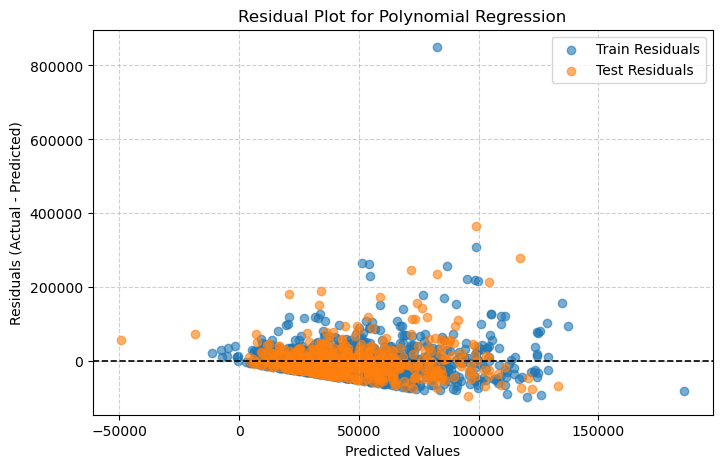

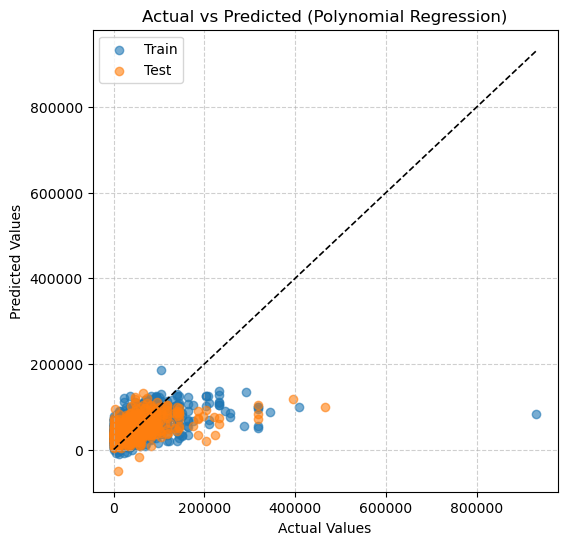

In [92]:
### TRYING TO GET THE PLOTS FOR BETTER UNDERSTANDING ###
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

reg = LinearRegression()

numeric_X_train = X_train.select_dtypes('int')
numeric_X_test = X_test.select_dtypes('int')

poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(numeric_X_train)
poly_features_test = poly.fit_transform(numeric_X_test)

reg.fit(poly_features, y_train)

print("\n=== Polynomial Regression Equation (degree=2) ===")
feature_names = poly.get_feature_names_out(numeric_X_train.columns)
for name, coef in zip(feature_names, reg.coef_):
    print(f"{name}: {coef:.6f}")
print(f"Intercept (β₀): {reg.intercept_:.6f}")

y_pred_train = reg.predict(poly_features)
y_pred_test = reg.predict(poly_features_test)

print('Train RMSE', root_mean_squared_error(y_train, y_pred_train))
print('Test RMSE', root_mean_squared_error(y_test, y_pred_test))

residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_train, residuals_train, alpha=0.6, label='Train Residuals')
plt.scatter(y_pred_test,  residuals_test,  alpha=0.6, label='Test Residuals')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for Polynomial Regression")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_pred_train, alpha=0.6, label='Train')
plt.scatter(y_test,  y_pred_test,  alpha=0.6, label='Test')

y_all = np.concatenate([np.asarray(y_train).ravel(), np.asarray(y_test).ravel()])
min_y, max_y = np.min(y_all), np.max(y_all)
plt.plot([min_y, max_y], [min_y, max_y], 'k--', linewidth=1.2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Polynomial Regression)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


=== Polynomial Regression Equation (degree=2) ===
age: 135.068263
height: -14131.047751
weight: -1262.097561
education: -25548.615413
walk: 8880.551497
exercise: -5836.500553
tense: -19269.264614
age^2: -24.919941
age height: 36.678917
age weight: -3.318909
age education: 43.547318
age walk: 4.836301
age exercise: 80.108477
age tense: -65.299808
height^2: 46.273249
height weight: 35.668724
height education: 305.563261
height walk: -131.981291
height exercise: 100.404871
height tense: 332.484532
weight^2: -2.865187
weight education: -3.392183
weight walk: 6.430383
weight exercise: -20.542786
weight tense: 31.801040
education^2: 312.589618
education walk: 36.675533
education exercise: 216.413727
education tense: -542.122341
walk^2: -141.653852
walk exercise: -106.176377
walk tense: -118.014161
exercise^2: -267.976692
exercise tense: 227.538029
tense^2: 240.549740
Intercept (β₀): 631319.471120
Train RMSE 46709.583075613555
Test RMSE 45381.95107983659


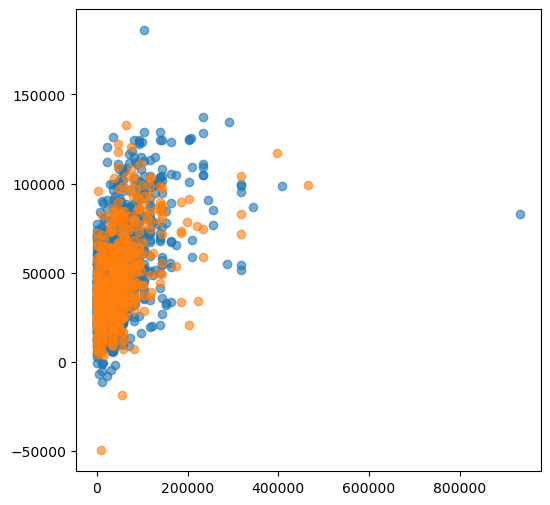

In [94]:
### TRYING TO GET THE PLOTS FOR BETTER UNDERSTANDING ###
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

reg = LinearRegression()

numeric_X_train = X_train.select_dtypes('int')
numeric_X_test = X_test.select_dtypes('int')

poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(numeric_X_train)
poly_features_test = poly.fit_transform(numeric_X_test)

reg.fit(poly_features, y_train)

print("\n=== Polynomial Regression Equation (degree=2) ===")
feature_names = poly.get_feature_names_out(numeric_X_train.columns)
for name, coef in zip(feature_names, reg.coef_):
    print(f"{name}: {coef:.6f}")
print(f"Intercept (β₀): {reg.intercept_:.6f}")

y_pred_train = reg.predict(poly_features)
y_pred_test = reg.predict(poly_features_test)

print('Train RMSE', root_mean_squared_error(y_train, y_pred_train))
print('Test RMSE', root_mean_squared_error(y_test, y_pred_test))

residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_pred_train, alpha=0.6, label='Train')
plt.scatter(y_test,  y_pred_test,  alpha=0.6, label='Test')

if numeric_X_train.shape[1] == 1:
    feature_name = numeric_X_train.columns[0]
    x_min = numeric_X_train[feature_name].min()
    x_max = numeric_X_train[feature_name].max()
    x_plot = np.linspace(x_min, x_max, 200).reshape(-1, 1)
    x_poly = poly.transform(x_plot)
    y_plot = reg.predict(x_poly)

    plt.figure(figsize=(8, 5))
    plt.scatter(numeric_X_train[feature_name], y_train, alpha=0.6, label='Train Data')
    plt.plot(x_plot, y_plot, linewidth=2, label='Polynomial Fit')
    plt.xlabel(feature_name)
    plt.ylabel("Target (y)")
    plt.title(f"Polynomial Regression Curve ({feature_name} → y)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [106]:
### TRYING TO GET THE PLOTS FOR BETTER UNDERSTANDING ###
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

reg = LinearRegression()

numeric_X_train = X_train.select_dtypes('int')
numeric_X_test = X_test.select_dtypes('int')

poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(numeric_X_train)
poly_features_test = poly.fit_transform(numeric_X_test)

reg.fit(poly_features, y_train)

print("\n=== Polynomial Regression Equation (Degree 2) ===")
age = poly.get_feature_names_out([age])
for name, coef in zip(feature_names, reg.coef_):
    print(f"{name}: {coef:.6f}")
print(f"Intercept (β₀): {reg.intercept_:.6f}")

y_pred_train = reg.predict(poly_features)
y_pred_test = reg.predict(poly_features_test)

print('Train RMSE', root_mean_squared_error(y_train, y_pred_train))
print('Test RMSE', root_mean_squared_error(y_test, y_pred_test))

residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

x_curve = np.linspace(x_train.min(), x_train.max(), 300).reshape(-1, 1)
x_curve_poly = poly.transform(x_curve)
y_curve = reg.predict(x_curve_poly)

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_tr, s=10, color='gray', alpha=0.5, label='Data Points')
plt.plot(x_curve, y_curve, color='red', linewidth=2.5, label='Polynomial Regression (Degree 2)')

plt.title("Polynomial Regression Fit")
plt.xlabel(feature_name)
plt.ylabel(y_label)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

residuals = y_tr - y_pred_train
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_train, residuals, color='blue', alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=1.2)
plt.title("Residual Plot for Polynomial Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


=== Polynomial Regression Equation (Degree 2) ===


NameError: name 'age' is not defined

In [100]:
## We will now use spline instead of polynomial features
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

numeric_X_train = X_train.select_dtypes('int')
numeric_X_test = X_test.select_dtypes('int')

from sklearn.preprocessing import SplineTransformer
spline = SplineTransformer(n_knots=3, degree=2)

spline_features = spline.fit_transform(numeric_X_train)
spline_features_test = spline.fit_transform(numeric_X_test)

reg.fit(spline_features, y_train)
y_pred_train = reg.predict(spline_features)
y_pred_test = reg.predict(spline_features_test)

from sklearn.metrics import root_mean_squared_error
print('Train RMSE', root_mean_squared_error(y_train, y_pred_train))
print('Test RMSE', root_mean_squared_error(y_test, y_pred_test))
##3nots 2 degree is better
#this should perform better coz the cuts in data are more intuitive and thoughtful
#nots is basically cluster

Train RMSE 46718.93723450403
Test RMSE 46109.36827641149


In [104]:
len(reg.coef_)
#as you inc the nots or degree this increases
# so if you do 4 nots and 3 degrees you get 42 as output

28

In [ ]:
## GAM Generalized Addative Models
#we let the function decide how many nots are appopriate and the degree too, this is truely non liner on parameters as well
